**# Diabetic Retinopathy Detection using EfficientNetB0**

Deep learning-based diabetic retinopathy classification using retinal fundus images and transfer learning.



In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

print(os.getcwd())
print(os.listdir())


/content
['.config', 'train.csv', 'sample_data']


In [ ]:
!unzip aptos2019-blindness-detection.zip -d aptos_data


Streaming output truncated to the last 5000 lines.
  inflating: aptos_data/test_images/512beaada8f0.png  
  inflating: aptos_data/test_images/51323e9d2070.png  
  inflating: aptos_data/test_images/515675001b9e.png  
  inflating: aptos_data/test_images/515877da2def.png  
  inflating: aptos_data/test_images/5168ddccea88.png  
  inflating: aptos_data/test_images/5172c056a687.png  
  inflating: aptos_data/test_images/5177461f5339.png  
  inflating: aptos_data/test_images/51910bcb980d.png  
  inflating: aptos_data/test_images/51a3e9b6a1c0.png  
  inflating: aptos_data/test_images/51bbd82feec8.png  
  inflating: aptos_data/test_images/51de5fb8eccd.png  
  inflating: aptos_data/test_images/51e88694c81f.png  
  inflating: aptos_data/test_images/51f0bf8f1544.png  
  inflating: aptos_data/test_images/51f57fb32840.png  
  inflating: aptos_data/test_images/51fa42dc1415.png  
  inflating: aptos_data/test_images/5276ab33b7b0.png  
  inflating: aptos_data/test_images/52a353760f72.png  
  inflating: a

In [ ]:
!unzip aptos_data/train_images.zip -d train_images


unzip:  cannot find or open aptos_data/train_images.zip, aptos_data/train_images.zip.zip or aptos_data/train_images.zip.ZIP.


In [ ]:
import pandas as pd

df = pd.read_csv("aptos_data/train.csv")

df.head()


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [ ]:
print(df.shape)

df['diagnosis'].value_counts()

(3662, 2)


,count
diagnosis,
0,1805
2,999
1,370
4,295
3,193


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import os

from sklearn.model_selection import train_test_split

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence

In [ ]:
df = pd.read_csv("aptos_data/train.csv")

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['diagnosis']
)

print("Training:", len(train_df))
print("Validation:", len(val_df))

Training: 2929
Validation: 733


In [ ]:
class RetinaGenerator(Sequence):

    def __init__(self, dataframe, batch_size=16):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size

    def __len__(self):
        return len(self.df)//self.batch_size

    def __getitem__(self, idx):

        batch = self.df.iloc[
            idx*self.batch_size:(idx+1)*self.batch_size
        ]

        images=[]
        labels=[]

        for _, row in batch.iterrows():

            path = f"aptos_data/train_images/{row['id_code']}.png"

            img = cv2.imread(path)

            img = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2RGB
            )

            img = cv2.resize(
                img,
                (224,224)
            )

            img = img/255.0

            images.append(img)

            labels.append(row['diagnosis'])

        return np.array(images), np.array(labels)

In [ ]:
train_gen = RetinaGenerator(train_df)

val_gen = RetinaGenerator(val_df)

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

output = Dense(
    5,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
import numpy as np

pred_classes = np.argmax(preds, axis=1)

print(np.unique(pred_classes))

[0]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df['diagnosis'])

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['diagnosis']
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.4056786703601108), np.int64(1): np.float64(1.979054054054054), np.int64(2): np.float64(0.7331664580725907), np.int64(3): np.float64(3.803896103896104), np.int64(4): np.float64(2.4822033898305085)}


In [ ]:
base_model.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 439s 2s/step - accuracy: 0.1028 - loss: 1.6903 - val_accuracy: 0.0653 - val_loss: 1.7527
Epoch 2/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.2913 - loss: 1.4606 - val_accuracy: 0.2778 - val_loss: 1.5841
Epoch 3/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.4874 - loss: 1.2883 - val_accuracy: 0.1264 - val_loss: 1.6432
Epoch 4/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.5683 - loss: 1.1752 - val_accuracy: 0.4236 - val_loss: 1.4021
Epoch 5/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.6349 - loss: 1.0883 - val_accuracy: 0.6264 - val_loss: 1.2153
Epoch 6/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.6636 - loss: 1.0202 - val_accuracy: 0.7014 - val_loss: 1.0719
Epoch 7/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.7036 - loss: 0.9580 - val_accuracy: 0.7194 - val_loss: 0.9750
Epoch 8/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.7210 - loss: 0.8961 - val_accu

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np

preds = model.predict(val_gen)

y_pred = np.argmax(preds, axis=1)

y_true = []

for _, labels in val_gen:
    y_true.extend(labels)

y_true = np.array(y_true[:len(y_pred)])

print(classification_report(y_true, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       357
           1       0.44      0.44      0.44        71
           2       0.65      0.66      0.66       196
           3       0.28      0.49      0.36        39
           4       0.26      0.16      0.20        57

    accuracy                           0.71       720
   macro avg       0.51      0.53      0.51       720
weighted avg       0.72      0.71      0.71       720



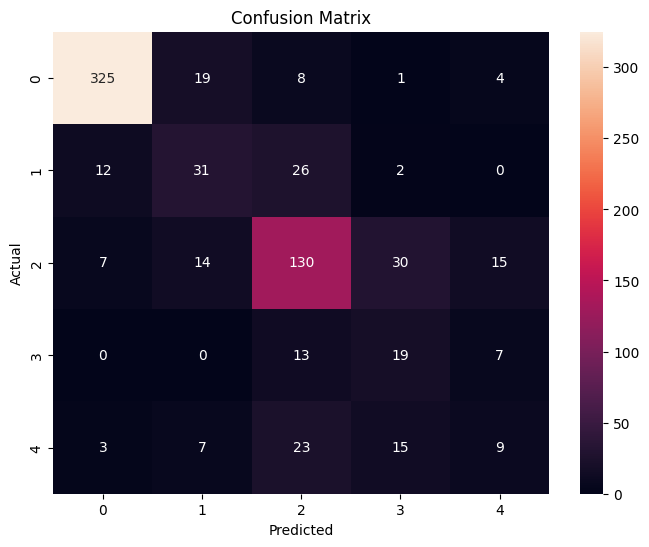

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save("diabetic_retinopathy_model.h5")

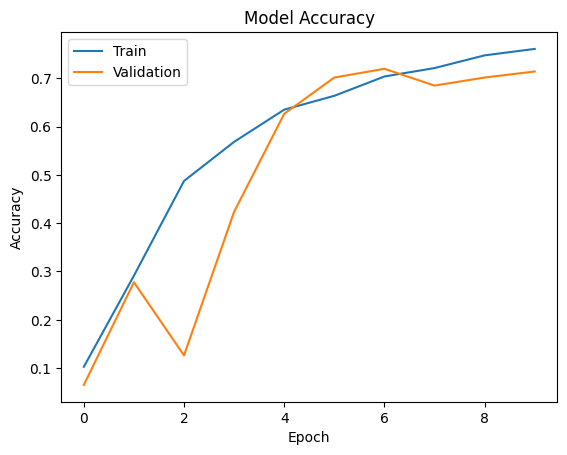

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
import random

random_image = random.choice(os.listdir("aptos_data/train_images"))

print(random_image)

d9ba044671e1.png


In [ ]:
import os

images = os.listdir("aptos_data/train_images")

print(images[:5])

['ae1344610ebe.png', 'f1d719c97838.png', 'e1ab92228e60.png', 'd1b279cc02ae.png', '155e2df6bfcf.png']


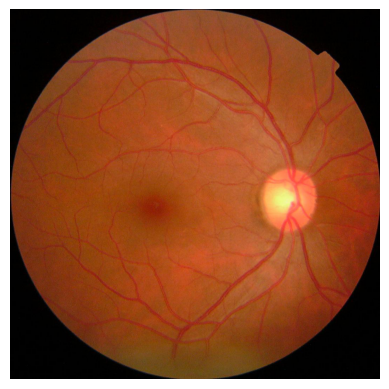

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("aptos_data/train_images/f1d719c97838.png")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
print(df.head())

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [ ]:
img = cv2.imread("aptos_data/train_images/f1d719c97838.png")

img = cv2.resize(img,(224,224))

img = img/255.0

img = np.expand_dims(img,axis=0)

pred = model.predict(img)

print(pred)

print("Predicted Class:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
[[0.5184743  0.17741388 0.14673458 0.05296096 0.10441633]]
Predicted Class: 0


In [ ]:
df[df['id_code'] == 'f1d719c97838']

,id_code,diagnosis
3478,f1d719c97838,0


In [ ]:
df[df['diagnosis'] == 4].head()

,id_code,diagnosis
1,001639a390f0,4
5,0083ee8054ee,4
32,0243404e8a00,4
34,02685f13cefd,4
38,02dda30d3acf,4


In [ ]:
import numpy as np

img = cv2.imread("aptos_data/train_images/0083ee8054ee.png")

img = cv2.resize(img,(224,224))

img = img/255.0

img = np.expand_dims(img,axis=0)

pred = model.predict(img)

print("Prediction Probabilities:")
print(pred)

print("Predicted Class:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction Probabilities:
[[0.347348   0.17120634 0.27758524 0.06149025 0.14237027]]
Predicted Class: 0


In [ ]:
df[df['id_code'] == '0083ee8054ee']

,id_code,diagnosis
5,0083ee8054ee,4


In [ ]:
from sklearn.metrics import classification_report

preds = model.predict(val_gen)

y_pred = np.argmax(preds, axis=1)

y_true = []

for _, labels in val_gen:
    y_true.extend(labels)

y_true = y_true[:len(y_pred)]

print(classification_report(y_true, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       357
           1       0.44      0.44      0.44        71
           2       0.65      0.66      0.66       196
           3       0.28      0.49      0.36        39
           4       0.26      0.16      0.20        57

    accuracy                           0.71       720
   macro avg       0.51      0.53      0.51       720
weighted avg       0.72      0.71      0.71       720



In [ ]:
## Results

Validation Accuracy: 71.39%

Weighted F1 Score: 0.71